### Linear Regression ###

### for more info visit https://www.interactive-ml.com/linear-regression.html ###

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme()

In [2]:
X = np.array([1 , 3, 4, 6, 7]) # Input feature: years of experience
y = np.array([15,35,45,65,75]) # Target value: salary (in thousands)

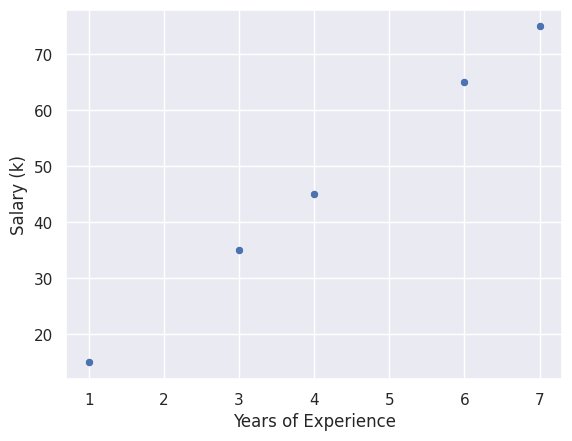

In [3]:
# Visualize the relationship between experience and salary
sns.scatterplot(x=X, y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.show()

#### Prediction FUnction ####

#### y=wX+b 

w=weight, b=bias, X=features, y=target
####

In [4]:
def make_prediction(X, y, w, b):
    
    m = len(X) # no of training examples 
    
    prediction_list = np.zeros(m) # empty list of zeros
    
    for i in range (m) :
        prediction_list[i]=w*X[i]+b 
    return prediction_list

[0. 0. 0. 0. 0.]


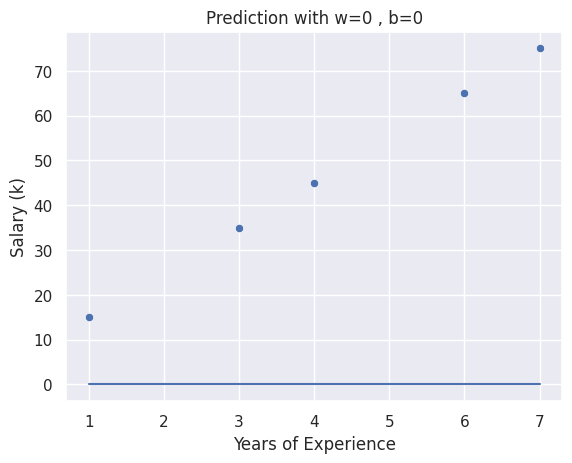

In [5]:
# testing with w=0 , b=0 
predictions = make_prediction(X,y,0,0)

print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions, label='Prediction with w=0 , b=0') # Ploting the prediction line
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.title("Prediction with w=0 , b=0")
plt.show()


[1. 3. 4. 6. 7.]


Text(0.5, 1.0, 'Prediction with w=1, b=0')

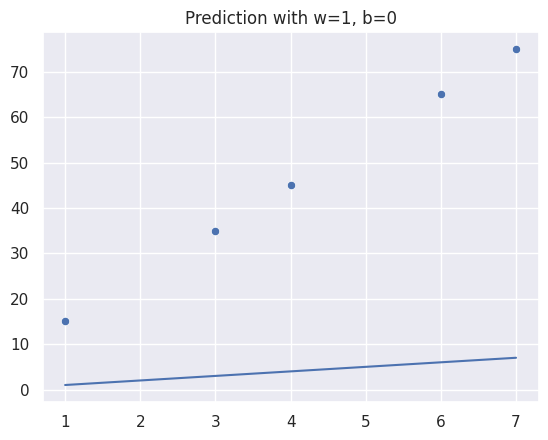

In [6]:
predictions = make_prediction(X,y,w=1,b=0)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)
plt.title("Prediction with w=1, b=0")

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Prediction with w=10 , b=5')

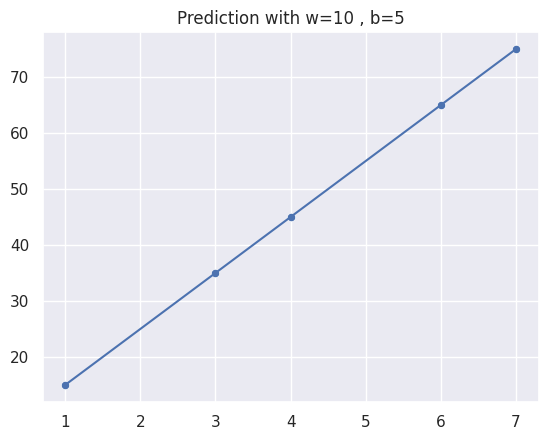

In [7]:
predictions = make_prediction(X,y,w=10,b=5)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)
plt.title("Prediction with w=10 , b=5")

### Cost Function ###
###
X   sal  pred error 

1             15               0              15^2

2      20         0         20^2

3      25         0         25^2

4      30         0         30^2

5      35         0         35 ^2
###

In [8]:
def compute_cost(X,y,w,b):
    
    m= len(X)
    
    cost =0 
    for i in range(m) :
        
        prediction = w*X[i]+b
        
        error = prediction -y[i] 
        error_squared = error**2  #Squaring makes big errors much more important than small ones.

        cost = cost + error_squared 
        
    return cost/m  # MSE mean suared error

       
        

In [9]:
cost = compute_cost(X,y,w=10,b=5)
print(cost)


0.0


### Cost  Function minimization  ###

#### lets keep b=0 and w=-100 to 100 to see how the cost changes with different weights  ###

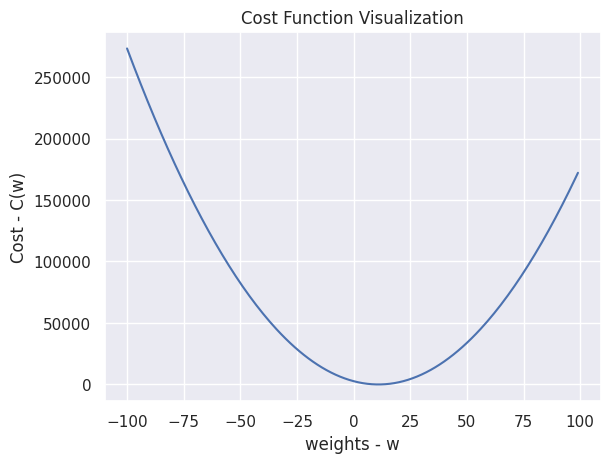

In [10]:
w_range= [] #list
cost_list = [] 


for i  in range (-100,100) :
    
     w_range.append(i)
     cost_list.append(compute_cost(X,y,w=i,b=0))
    
#plot 
plt.plot(w_range , cost_list)
plt.xlabel("weights - w")
plt.ylabel("Cost - C(w)")
plt.title("Cost Function Visualization")
plt.show()  

   

## Gradient Descent Algorithm ##

#### to find the minimum value of a cost (loss) function. The basic update rule is:  

θ:=θ− α * ∇J(θ) 

θ (theta) = model parameters (weights)

α (alpha) = learning rate (step size)

J(θ) = cost/loss function

∇J(θ) = gradient , how much cost changes with respect to w/b

steps : 

Initialize parameters randomly.

Compute the loss.

Calculate the gradient of the loss with respect to parameters.

Move parameters in the opposite direction of the gradient.

Repeat until convergence.####

for a curve (rises from left to right) the gradient is positive, so we subtract it from the parameters to move down the curve. For a curve that falls from left to right, the gradient is negative, so subtracting it effectively adds to the parameters, moving us up the curve towards the minimum. 

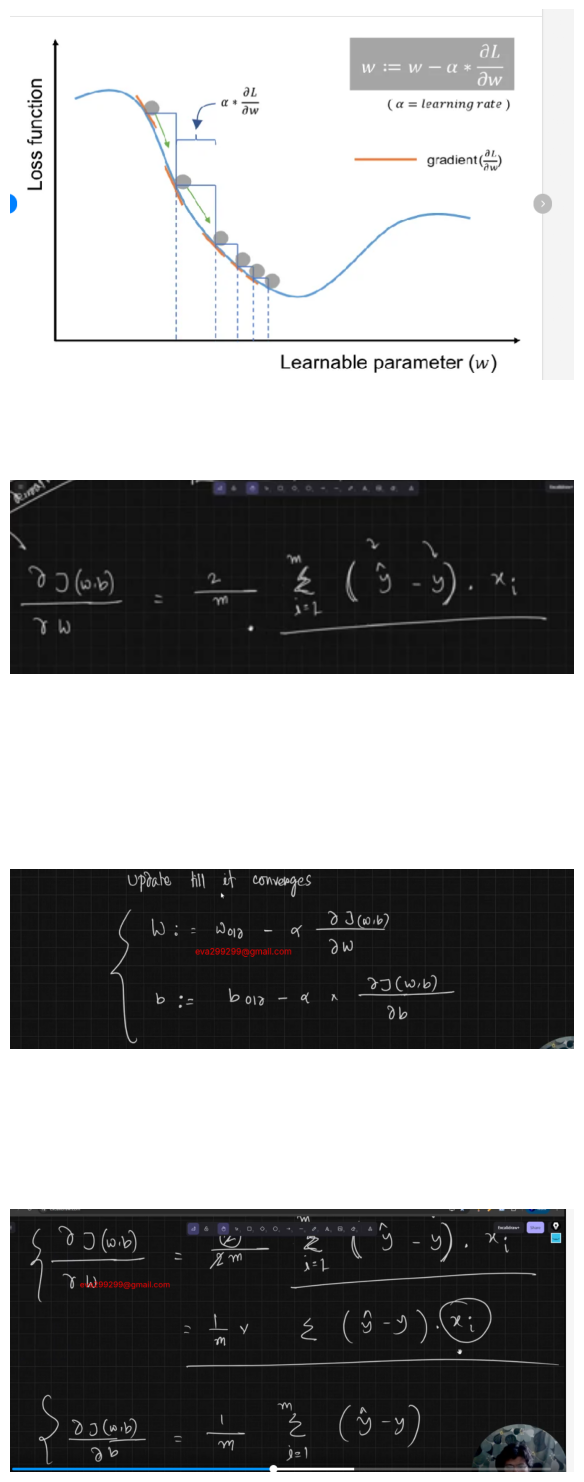

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(6, 16))

for ax, image_path in zip(axes, ['gradient.png', 'img.png', 'img2.png', 'img3.png']):
    ax.imshow(plt.imread(image_path))
    ax.axis('off')

plt.tight_layout()


#### Gradient Descent calculation  ####

In [37]:
def calculate_gradient(X,y,w,b) :
    
    m = len(X)
    dj_dw=0.0
    dj_db=0.0
    
    for i in range(m) :
        
        prediction = w*X[i]+b
        error =prediction-y[i]
        
        dj_dw = dj_dw + error*X[i]
        dj_db = dj_db + error
        
    return dj_dw/m , dj_db/m        
        

In [56]:
def  gradient_descent(X, y , w, b , max_iter, alpha=0.01) :
    cost_memo= []
    
    for i in range(max_iter) :
        dj_dw, dj_db = calculate_gradient(X, y, w, b) #
        
        w= w - alpha * dj_dw # Update weight by alpha rate until we reach the minimum cost
        b= b - alpha * dj_db
        
        cost = compute_cost(X,y,w,b)
        cost_memo.append(cost)
        
        if(i%100==0) :
            print(f"Iteration {i} : Cost {cost : 0.4f} , w {w : 0.4f} , b {b : 0.4f}")
            
    return w,b,cost ,cost_memo   , max_iter      


In [58]:
w_final , b_final , cost_final , cost_list , max_iter = gradient_descent(X,y,w=0,b=0,max_iter=10000)
print(f"Final parameters : w {w_final : 0.4f} , b {b_final : 0.4f} , cost {cost_final : 0.4f}")
print(f"Number of iterations: {len(cost_list)}")

Iteration 0 : Cost  1580.7433 , w  2.4300 , b  0.4700
Iteration 100 : Cost  1.2240 , w  10.4659 , b  2.5593
Iteration 200 : Cost  0.8230 , w  10.3821 , b  2.9986
Iteration 300 : Cost  0.5534 , w  10.3133 , b  3.3588
Iteration 400 : Cost  0.3721 , w  10.2569 , b  3.6542
Iteration 500 : Cost  0.2502 , w  10.2107 , b  3.8965
Iteration 600 : Cost  0.1683 , w  10.1727 , b  4.0951
Iteration 700 : Cost  0.1131 , w  10.1416 , b  4.2580
Iteration 800 : Cost  0.0761 , w  10.1162 , b  4.3915
Iteration 900 : Cost  0.0512 , w  10.0952 , b  4.5010
Iteration 1000 : Cost  0.0344 , w  10.0781 , b  4.5909
Iteration 1100 : Cost  0.0231 , w  10.0640 , b  4.6645
Iteration 1200 : Cost  0.0156 , w  10.0525 , b  4.7249
Iteration 1300 : Cost  0.0105 , w  10.0431 , b  4.7744
Iteration 1400 : Cost  0.0070 , w  10.0353 , b  4.8150
Iteration 1500 : Cost  0.0047 , w  10.0290 , b  4.8483
Iteration 1600 : Cost  0.0032 , w  10.0237 , b  4.8756
Iteration 1700 : Cost  0.0021 , w  10.0195 , b  4.8980
Iteration 1800 : Cos

the dj_dw and dj_db section. The values are decreasing and tending to zero over the iterations. That means , once the algorithm converges to it's minimum point of the function , it kinda stop updating the parameters ( w and b )

### Final Prediction and cost ###

Final parameters : w  10.0000 , b  5.0000 , cost  0.0000
Final prediction: [14.99999999 35.         45.         65.         75.        ]


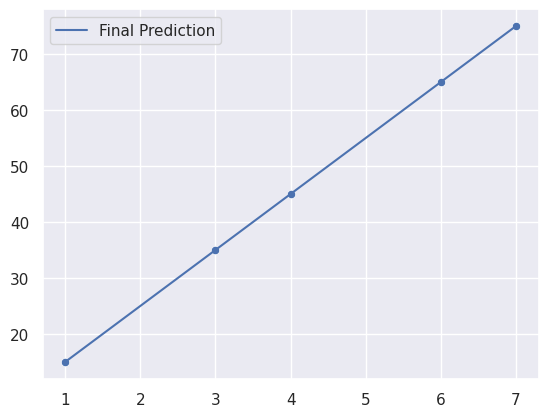

In [59]:
print(f"Final parameters : w {w_final : 0.4f} , b {b_final : 0.4f} , cost {cost_final : 0.4f}")

final_prediction = make_prediction(X,y,w_final,b_final)
print(f"Final prediction: {final_prediction}")

sns.scatterplot(x= X , y = y)
plt.plot(X , final_prediction, label='Final Prediction') # Ploting the prediction line
plt.legend()
plt.show()


### Predicting Predicting salary for someone with 2 years of experience ###

In [60]:
experience_X =2 

prediction_for_2_years = w_final*experience_X + b_final
print(f"Predicted salary for 2 years of experience: {prediction_for_2_years : 0.4f}k")

Predicted salary for 2 years of experience:  25.0000k


Plotting the cost over the first 20 iterations to see it dropping


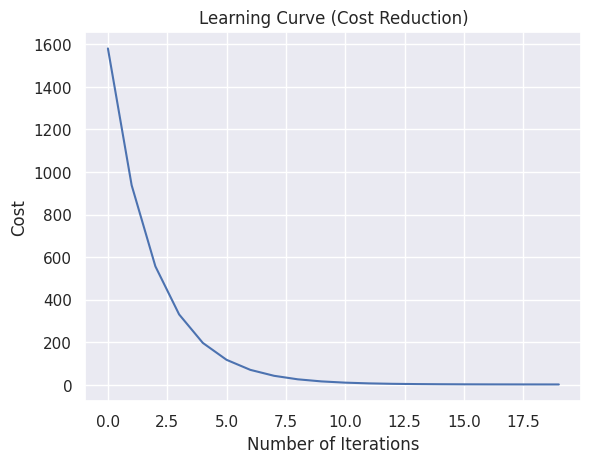

In [64]:
plt.plot(range(20), cost_list[:20])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()
     

how cost is dropping over the iterations towards the minimum point of the cost function